In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import deepxde as dde
dde.backend.set_default_backend("pytorch")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [2]:
# =========================
# Blood + flow parameters
# =========================
rho = 1060.0          # kg/m^3
mu  = 3.5e-3          # Pa*s  (dynamic viscosity)
nu  = mu / rho        # m^2/s (kinematic viscosity)

U_mean = 0.20         # m/s (choose)
U_max  = 2.0 * U_mean # m/s (parabolic peak)


In [3]:
# =========================
# Vessel geometry parameters (meters)
# =========================
R_in   = 2.0e-3       # inlet radius 2 mm
R_b    = 1.5e-3       # branch radius 1.5 mm
L_tr   = 20e-3        # trunk length 20 mm
L_br   = 20e-3        # branch length 20 mm
y_off  = 3.0e-3       # branch center offset 3 mm

x_min  = -L_tr
x_max  =  L_br

# Split inner point (controls the sharpness of the divider)
x_split_inner = 2.0e-3


In [4]:
# =========================
# Y-bifurcation polygon (simple, non-self-intersecting)
# =========================
vertices = [
    [x_min,  +R_in],          # inlet top
    [0.0,    +R_in],          # trunk top to split
    [x_max,  y_off + R_b],    # upper branch outer top at outlet
    [x_max,  y_off - R_b],    # upper outlet lower corner (vertical outlet segment)
    [x_split_inner, 0.0],     # inner split tip
    [x_max, -y_off + R_b],    # lower outlet upper corner
    [x_max, -y_off - R_b],    # lower branch outer bottom at outlet
    [0.0,    -R_in],          # trunk bottom to split
    [x_min,  -R_in],          # inlet bottom
]

def ensure_ccw(verts):
    v = np.array(verts, dtype=float)
    x, y = v[:, 0], v[:, 1]
    area2 = np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
    return v.tolist() if area2 > 0 else v[::-1].tolist()

vertices = ensure_ccw(vertices)
geom = dde.geometry.Polygon(vertices)

In [5]:
# =========================
# Boundary markers (robust isclose: rtol=0)
# =========================
ATOL = 1e-6  # meters (try 1e-5 if still missing)

def isclose0(a, b):
    return np.isclose(a, b, atol=ATOL, rtol=0.0)

def boundary_inlet(x, on_boundary):
    return on_boundary and isclose0(x[0], x_min) and (-R_in-ATOL <= x[1] <= R_in+ATOL)

def boundary_outlet_top(x, on_boundary):
    return on_boundary and isclose0(x[0], x_max) and (y_off-R_b-ATOL <= x[1] <= y_off+R_b+ATOL)

def boundary_outlet_bottom(x, on_boundary):
    return on_boundary and isclose0(x[0], x_max) and (-y_off-R_b-ATOL <= x[1] <= -y_off+R_b+ATOL)

def boundary_wall(x, on_boundary):
    return on_boundary and (not boundary_inlet(x, True)) and \
           (not boundary_outlet_top(x, True)) and (not boundary_outlet_bottom(x, True))

In [6]:
# =========================
# BC value functions must return (N,1)
# =========================
def const(val):
    return lambda X: np.full((len(X), 1), val)

def inlet_u_parabolic(Umax, R):
    # u(y)=Umax*(1-(y/R)^2), v=0
    def f(X):
        y = X[:, 1:2]
        return Umax * (1.0 - (y / R) ** 2)
    return f

In [7]:
# =========================
# BCs for outputs [u, v, p]
# =========================
bc_wall_u = dde.DirichletBC(geom, const(0.0), boundary_wall, component=0)
bc_wall_v = dde.DirichletBC(geom, const(0.0), boundary_wall, component=1)

bc_inlet_u = dde.DirichletBC(geom, inlet_u_parabolic(U_max, R_in), boundary_inlet, component=0)
bc_inlet_v = dde.DirichletBC(geom, const(0.0), boundary_inlet, component=1)

# Pressure outlets (gauge pressure)
bc_outlet_top_p = dde.DirichletBC(geom, const(0.0), boundary_outlet_top, component=2)
bc_outlet_bot_p = dde.DirichletBC(geom, const(0.0), boundary_outlet_bottom, component=2)

bcs = [
    bc_wall_u, bc_wall_v,
    bc_inlet_u, bc_inlet_v,
    bc_outlet_top_p, bc_outlet_bot_p,
]

In [8]:
def pde(X, Y):
    du_x = dde.grad.jacobian(Y, X, i=0, j=0)
    du_y = dde.grad.jacobian(Y, X, i=0, j=1)
    dv_x = dde.grad.jacobian(Y, X, i=1, j=0)
    dv_y = dde.grad.jacobian(Y, X, i=1, j=1)
    dp_x = dde.grad.jacobian(Y, X, i=2, j=0)
    dp_y = dde.grad.jacobian(Y, X, i=2, j=1)

    du_xx = dde.grad.hessian(Y, X, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(Y, X, component=0, i=1, j=1)
    dv_xx = dde.grad.hessian(Y, X, component=1, i=0, j=0)
    dv_yy = dde.grad.hessian(Y, X, component=1, i=1, j=1)

    u = Y[:, 0:1]
    v = Y[:, 1:2]

    pde_u = u * du_x + v * du_y + (1.0 / rho) * dp_x - nu * (du_xx + du_yy)
    pde_v = u * dv_x + v * dv_y + (1.0 / rho) * dp_y - nu * (dv_xx + dv_yy)
    pde_cont = du_x + dv_y

    return [pde_u, pde_v, pde_cont]

In [15]:
# Create Data Object
data = dde.data.PDE(
    geom,
    pde, # Use your existing pde function
    bcs,
    num_domain=4000,
    num_boundary=2000,
    num_test=500
)

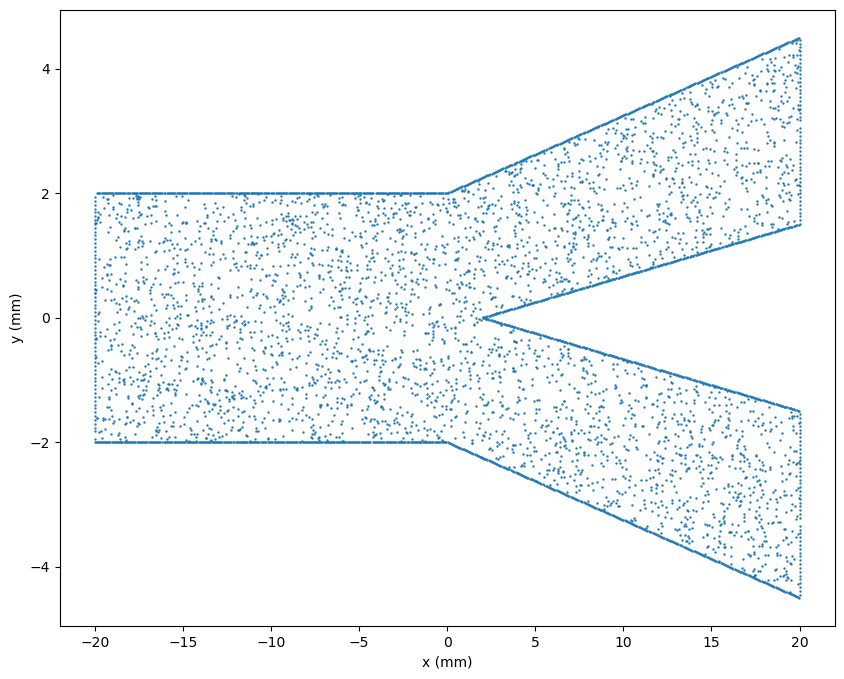

In [16]:
plt.figure(figsize=(10,8))
plt.scatter(data.train_x_all[:,0]*1000, data.train_x_all[:,1]*1000, s= 0.5)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.show()

In [17]:
pts = geom.random_boundary_points(3000)

cnt_in  = sum(boundary_inlet(p, True) for p in pts)
cnt_ot  = sum(boundary_outlet_top(p, True) for p in pts)
cnt_ob  = sum(boundary_outlet_bottom(p, True) for p in pts)
cnt_w   = sum(boundary_wall(p, True) for p in pts)

print("Boundary sample counts:")
print(" inlet:", cnt_in)
print(" outlet_top:", cnt_ot)
print(" outlet_bottom:", cnt_ob)
print(" wall:", cnt_w)

Boundary sample counts:
 inlet: 96
 outlet_top: 61
 outlet_bottom: 65
 wall: 2778


In [18]:
net = dde.nn.FNN([2] + [64]*5 + [3] , "tanh", "Glorot uniform")

In [19]:
model = dde.Model(data, net)

model.compile("adam", lr=1e-3)

Compiling model...
'compile' took 0.000623 s



In [20]:
losshistory, train_state = model.train(epochs = 5000)

Training model...

0         [1.74e-06, 2.81e-06, 2.07e-01, 2.54e-05, 1.23e-05, 8.31e-02, 3.60e-05, 1.80e-06, 2.95e-07]    [1.69e-06, 2.71e-06, 2.07e-01, 2.54e-05, 1.23e-05, 8.31e-02, 3.60e-05, 1.80e-06, 2.95e-07]    []  
1000      [5.43e-04, 2.26e-06, 3.15e-08, 1.69e-02, 1.52e-04, 3.16e-02, 1.60e-04, 8.08e-08, 2.18e-06]    [5.43e-04, 2.22e-06, 3.00e-08, 1.69e-02, 1.52e-04, 3.16e-02, 1.60e-04, 8.08e-08, 2.18e-06]    []  
2000      [2.85e-04, 1.67e-06, 1.91e-07, 1.38e-02, 7.59e-04, 3.07e-02, 1.06e-03, 2.86e-06, 2.89e-06]    [2.86e-04, 1.56e-06, 1.90e-07, 1.38e-02, 7.59e-04, 3.07e-02, 1.06e-03, 2.86e-06, 2.89e-06]    []  
3000      [5.62e-05, 9.96e-07, 9.16e-06, 9.72e-03, 8.53e-04, 1.99e-02, 3.33e-03, 5.17e-08, 4.33e-08]    [5.46e-05, 8.19e-07, 9.10e-06, 9.72e-03, 8.53e-04, 1.99e-02, 3.33e-03, 5.17e-08, 4.33e-08]    []  
4000      [3.78e-05, 8.18e-07, 1.80e-07, 1.02e-02, 8.01e-04, 1.97e-02, 3.06e-03, 2.96e-08, 3.17e-08]    [3.67e-05, 6.66e-07, 1.72e-07, 1.02e-02, 8.01e-04, 1.97e-02, 3.06

Saving loss history to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/loss.dat ...
Saving training data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/train.dat ...
Saving test data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/test.dat ...


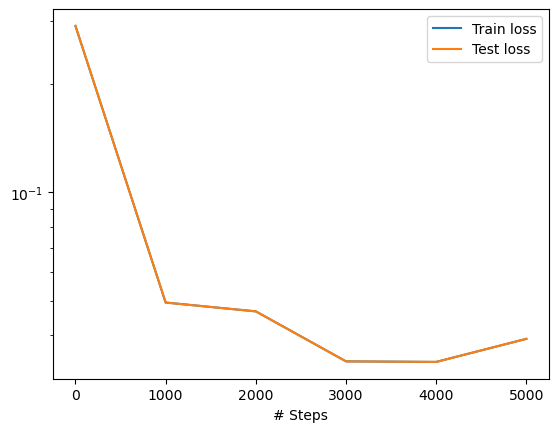

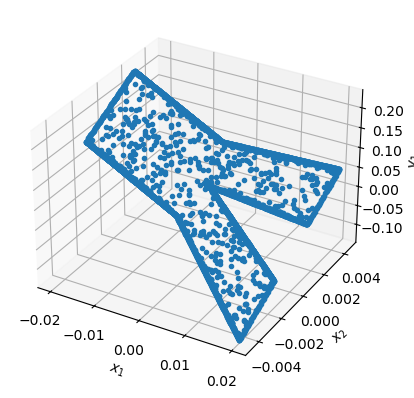

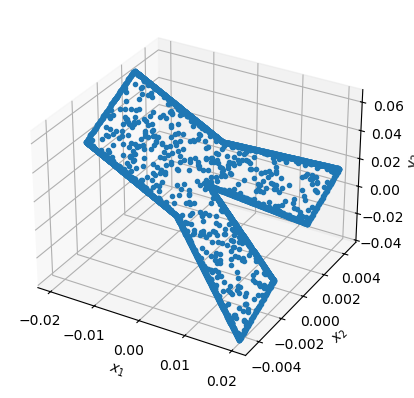

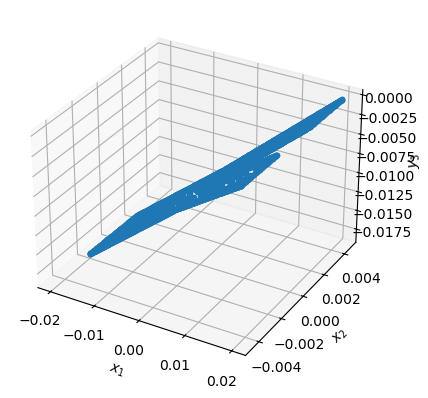

In [21]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

In [22]:
samples = geom.random_points(500000)
result = model.predict(samples)

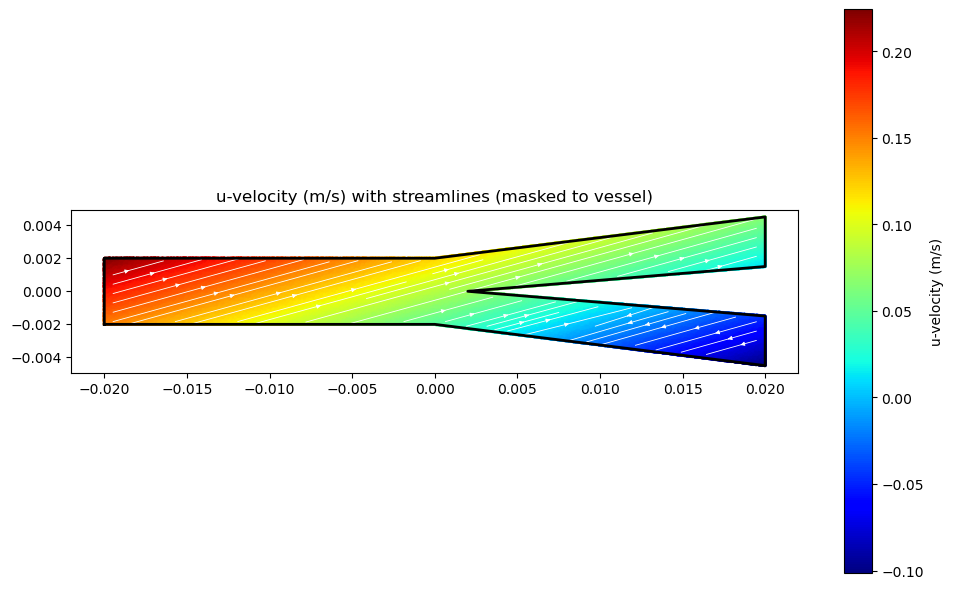

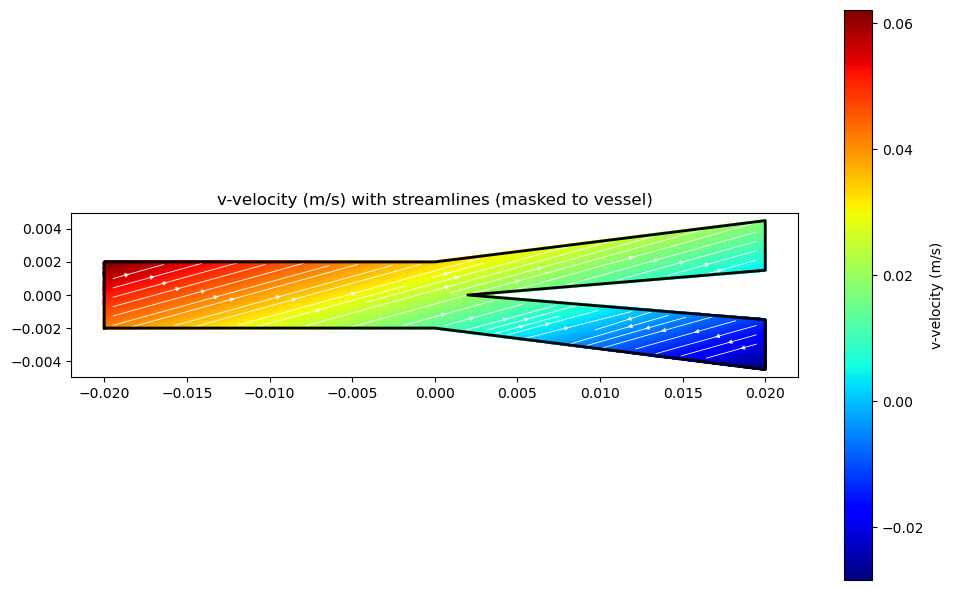

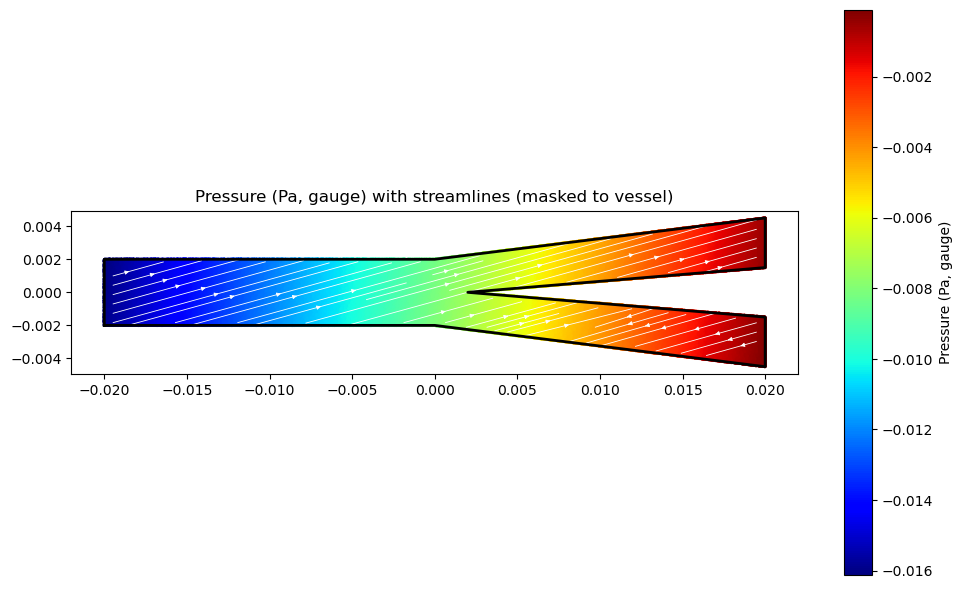

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
from matplotlib.path import Path

# ----------------------------------------
# 0) Bounds from the polygon (meters)
# ----------------------------------------
poly = np.array(vertices, dtype=float)
xmin, ymin = poly.min(axis=0)
xmax, ymax = poly.max(axis=0)

# Add padding so the plot isn't tight to walls
padx = 0.05 * (xmax - xmin)
pady = 0.05 * (ymax - ymin)

# ----------------------------------------
# 1) Regular grid for streamlines
# ----------------------------------------
nx, ny = 350, 350
grid_x = np.linspace(xmin - padx, xmax + padx, nx)
grid_y = np.linspace(ymin - pady, ymax + pady, ny)
GridX, GridY = np.meshgrid(grid_x, grid_y)

# ----------------------------------------
# 2) Interpolate u,v onto the grid
# ----------------------------------------
# samples: (N,2) points used for plotting/prediction
# result:  (N,3) predicted [u,v,p] at those samples
grid_u = griddata(samples, result[:, 0], (GridX, GridY), method="linear")
grid_v = griddata(samples, result[:, 1], (GridX, GridY), method="linear")

# ----------------------------------------
# 3) Mask outside polygon
# ----------------------------------------
path = Path(poly)
pts = np.c_[GridX.ravel(), GridY.ravel()]
inside = path.contains_points(pts).reshape(GridX.shape)

grid_u = np.where(inside, grid_u, np.nan)
grid_v = np.where(inside, grid_v, np.nan)

# Optional: if streamplot complains about NaNs inside the domain, uncomment:
# grid_u = np.nan_to_num(grid_u, nan=0.0)
# grid_v = np.nan_to_num(grid_v, nan=0.0)

# ----------------------------------------
# 4) Plot
# ----------------------------------------
field_names = ["u-velocity (m/s)", "v-velocity (m/s)", "Pressure (Pa, gauge)"]

for idx in range(3):
    plt.figure(figsize=(10, 6))

    sc = plt.scatter(samples[:, 0], samples[:, 1], c=result[:, idx], cmap="jet", s=2)
    plt.colorbar(sc, label=field_names[idx])

    # streamlines only make sense for u/v, but it's ok to overlay them for all
    plt.streamplot(GridX, GridY, grid_u, grid_v,
                   color="white", linewidth=0.6, arrowsize=0.6, density=1.2)

    # polygon outline
    poly_closed = np.vstack([poly, poly[0]])
    plt.plot(poly_closed[:, 0], poly_closed[:, 1], "k-", linewidth=2)

    plt.xlim(xmin - padx, xmax + padx)
    plt.ylim(ymin - pady, ymax + pady)

    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"{field_names[idx]} with streamlines (masked to vessel)")
    plt.tight_layout()
    plt.show()

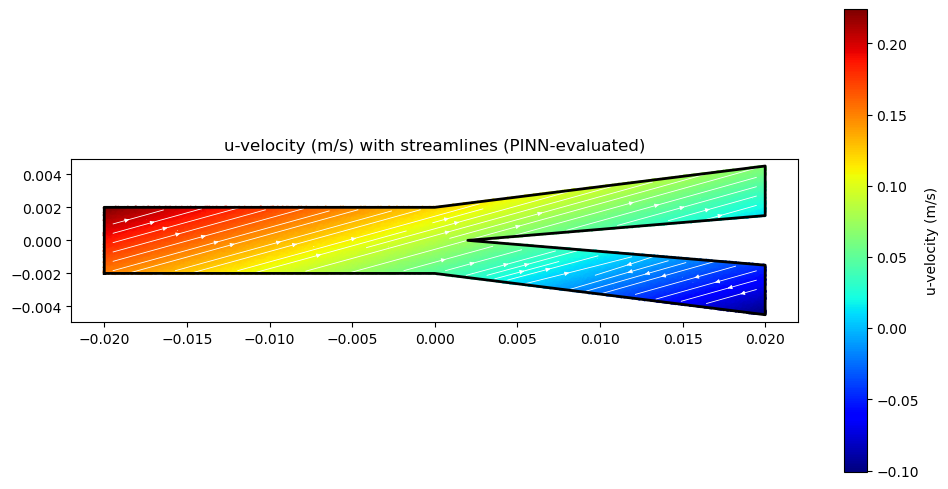

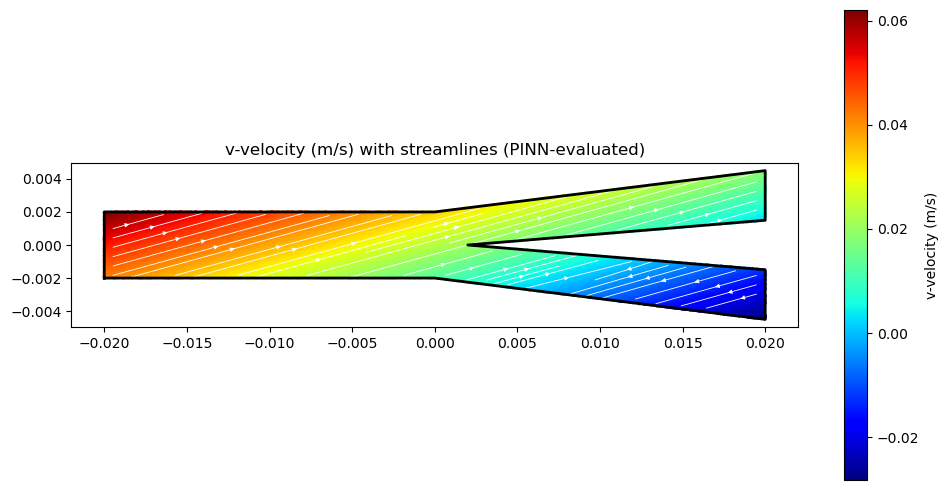

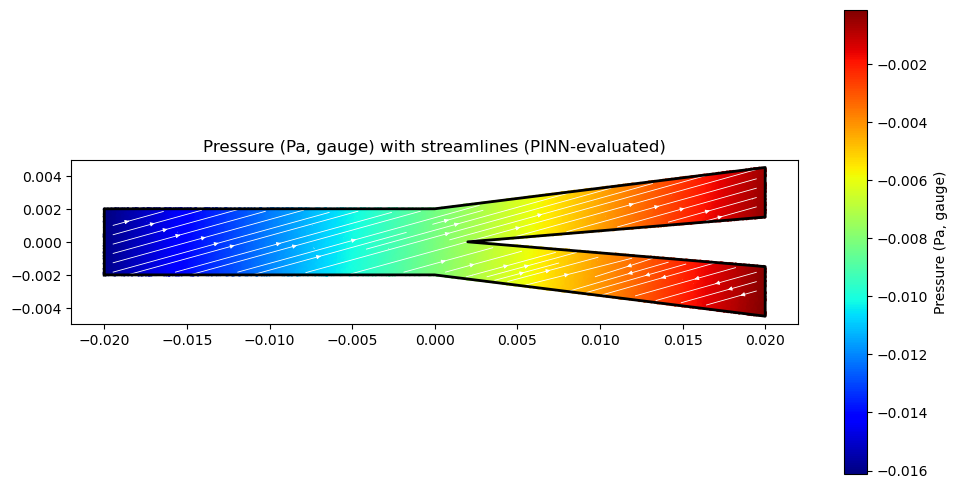

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path

# -----------------------------
# 0) Create fresh samples (scatter)
# -----------------------------
Ns = 50000
samples = geom.random_points(Ns)
result = model.predict(samples)   # (Ns,3) = [u,v,p]

# -----------------------------
# 1) Grid based on polygon bounds
# -----------------------------
poly = np.array(vertices, dtype=float)
xmin, ymin = poly.min(axis=0)
xmax, ymax = poly.max(axis=0)

padx = 0.05 * (xmax - xmin)
pady = 0.05 * (ymax - ymin)

nx, ny = 350, 350
grid_x = np.linspace(xmin - padx, xmax + padx, nx)
grid_y = np.linspace(ymin - pady, ymax + pady, ny)
GridX, GridY = np.meshgrid(grid_x, grid_y)

# -----------------------------
# 2) Mask: inside polygon
# -----------------------------
path = Path(poly)
pts = np.c_[GridX.ravel(), GridY.ravel()]
inside = path.contains_points(pts).reshape(GridX.shape)

# -----------------------------
# 3) Evaluate PINN on grid INSIDE only (no interpolation!)
# -----------------------------
grid_u = np.full(GridX.shape, np.nan)
grid_v = np.full(GridX.shape, np.nan)

XY_in = np.c_[GridX[inside], GridY[inside]]
UVP_in = model.predict(XY_in)  # (Ninside,3)

grid_u[inside] = UVP_in[:, 0]
grid_v[inside] = UVP_in[:, 1]

# -----------------------------
# 4) Plot
# -----------------------------
field_names = ["u-velocity (m/s)", "v-velocity (m/s)", "Pressure (Pa, gauge)"]

for idx in range(3):
    plt.figure(figsize=(10, 5))

    sc = plt.scatter(samples[:, 0], samples[:, 1], c=result[:, idx], cmap="jet", s=2)
    plt.colorbar(sc, label=field_names[idx])

    plt.streamplot(GridX, GridY, grid_u, grid_v,
                   color="white", linewidth=0.6, arrowsize=0.6, density=1.2)

    poly_closed = np.vstack([poly, poly[0]])
    plt.plot(poly_closed[:, 0], poly_closed[:, 1], "k-", linewidth=2)

    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlim(xmin - padx, xmax + padx)
    plt.ylim(ymin - pady, ymax + pady)
    plt.title(f"{field_names[idx]} with streamlines (PINN-evaluated)")
    plt.tight_layout()
    plt.show()

In [26]:
# sample boundary points and check BC errors
B = geom.random_boundary_points(4000)
Yb = model.predict(B)
uB, vB, pB = Yb[:,0], Yb[:,1], Yb[:,2]

idx_wall = np.array([boundary_wall(x, True) for x in B])
idx_in   = np.array([boundary_inlet(x, True) for x in B])
idx_ot   = np.array([boundary_outlet_top(x, True) for x in B])
idx_ob   = np.array([boundary_outlet_bottom(x, True) for x in B])

print("wall slip max |u|,|v|:", np.max(np.abs(uB[idx_wall])), np.max(np.abs(vB[idx_wall])))
print("outlet top mean p:", np.mean(pB[idx_ot]), "  outlet bot mean p:", np.mean(pB[idx_ob]))
print("inlet mean v:", np.mean(vB[idx_in]))

wall slip max |u|,|v|: 0.22456492 0.06220956
outlet top mean p: -0.00046841562   outlet bot mean p: -0.00017456735
inlet mean v: 0.051855817


In [ ]:
dde.optimizers.config.set_LBFGS_options(maxiter= 10000)
model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

In [ ]:
color_legend = [[0, 1.5], [-0.3, 0.3], [0, 35]]

for idx in range(3):
    plt.figure(figsize=(10, 6)) # Adjusted figsize for the Y-shape aspect ratio
    plt.scatter(samples[:, 0],
                samples[:, 1],
                c=result[:, idx],
                cmap='jet',
                s=2)
    plt.colorbar()
    plt.clim(color_legend[idx])
    
    # Update limits to match the Y-shaped polygon bounding box
    plt.xlim(-1.1, 1.1)  # Slightly larger than [-1, 1]
    plt.ylim(-0.9, 0.9)  # Slightly larger than [-0.8, 0.8]
    
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==========================================
# 1. Constants (Y-Shape Geometry)
# ==========================================
X_INLET  = -1.0
X_OUTLET =  1.0
Y_INLET_BOTTOM = -0.2
Y_INLET_TOP    =  0.2

# Physics
FLUID_RHO = 1.0       
FLUID_MU  = 1.0      
PARTICLE_D = 0.01     
PARTICLE_RHO = 10.0   

# Derived
PARTICLE_A = np.pi * (PARTICLE_D / 2)**2
PARTICLE_MASS = PARTICLE_RHO * (4/3) * np.pi * (PARTICLE_D / 2)**3

# ==========================================
# 2. Physics & Collision Logic
# ==========================================
def get_drag_coefficient(Re):
    if Re <= 0: return 0.0
    if Re < 1000: return (24.0 / Re) * (1 + 0.15 * (Re**0.687))
    return 0.44

def particle_momentum_eq(t, state, model):
    xp, yp, up, vp = state
    
    # Predict Fluid Velocity
    pos_tensor = np.array([[xp, yp]])
    fluid_vars = model.predict(pos_tensor)
    ug, vg = fluid_vars[0, 0], fluid_vars[0, 1]
    
    # Drag Force
    u_rel, v_rel = ug*5 - up, vg*5 - vp
    v_rel_mag = np.sqrt(u_rel**2 + v_rel**2)
    Re_p = (FLUID_RHO * v_rel_mag * PARTICLE_D) / FLUID_MU
    Cd = get_drag_coefficient(Re_p)
    coeff = (0.5 * Cd * PARTICLE_A * FLUID_RHO * v_rel_mag) / PARTICLE_MASS
    
    return [up, vp, coeff * u_rel, coeff * v_rel]

# --- COLLISION EVENTS ---

def outlet_event(t, state, model):
    """Trigger when particle reaches X = 1.0"""
    return state[0] - X_OUTLET
outlet_event.terminal = True
outlet_event.direction = 1

def wall_collision_event(t, state, model):
    """
    Trigger if particle hits ANY wall (Outer or Inner Wedge).
    Returns negative if collision occurs.
    """
    x, y = state[0], state[1]
    
    # 1. Check Outer Walls (Top/Bottom Limits)
    # Top Outer Wall: (0, 0.2) to (1, 0.8) -> y = 0.6*x + 0.2
    # Bottom Outer Wall: (0, -0.2) to (1, -0.8) -> y = -0.6*x - 0.2
    if x > 0:
        dist_top = (0.6 * x + 0.2) - y
        dist_bot = y - (-0.6 * x - 0.2)
    else:
        dist_top = 0.2 - y
        dist_bot = y - (-0.2)

    # 2. Check Inner Wedge (The Splitter)
    # Wedge starts at x > 0.2. 
    # Top Inner: y = 0.5 * (x - 0.2)
    # Bottom Inner: y = -0.5 * (x - 0.2)
    # Particle is safe if |y| > 0.5 * (x - 0.2)
    if x > 0.2:
        wedge_boundary_y = 0.5 * (x - 0.2)
        dist_wedge = abs(y) - wedge_boundary_y # Negative if inside wedge
    else:
        dist_wedge = 1.0 # Safe (no wedge here)

    # Return the smallest distance (if any is < 0, collision happened)
    return min(dist_top, dist_bot, dist_wedge)

wall_collision_event.terminal = True 

# ==========================================
# 3. Tracing & Plotting
# ==========================================
def trace_and_plot_particles(model, n_particles=15, t_max=8.0):
    print(f"Releasing {n_particles} particles...")
    plt.figure(figsize=(10, 6))
    
    # --- Draw Geometry ---
    plt.plot([-1, 0, 1], [0.2, 0.2, 0.8], 'k-', lw=2)  # Outer Top
    plt.plot([-1, 0, 1], [-0.2, -0.2, -0.8], 'k-', lw=2) # Outer Bottom
    plt.plot([0.2, 1], [0, 0.4], 'k-', lw=2)    # Inner Top
    plt.plot([0.2, 1], [0, -0.4], 'k-', lw=2)   # Inner Bottom
    plt.plot([-1, -1], [-0.2, 0.2], 'k--', label='Inlet')

    # Release points
    start_y = np.linspace(Y_INLET_BOTTOM + 0.02, Y_INLET_TOP - 0.02, n_particles)
    
    for y0 in start_y:
        init = [X_INLET, y0, 0.0, 0.0] # x, y, u, v
        
        sol = solve_ivp(
            fun=particle_momentum_eq,
            t_span=[0, t_max],
            y0=init,
            args=(model,),
            # Stop at Outlet OR Wall Collision
            events=[outlet_event, wall_collision_event], 
            rtol=1e-4, atol=1e-6,
            dense_output=True
        )
        
        x, y = sol.y[0], sol.y[1]
        
        # Color Logic: Blue = Exit, Red = Wall Hit, Green = Still in domain
        color = 'green'
        status_label = ""
        
        if sol.status == 1: # Event triggered
            # Check which event triggered it
            if abs(x[-1] - X_OUTLET) < 0.05: 
                color = 'blue'  # Reached Outlet
            else:
                color = 'red'   # Hit Wall
        
        plt.plot(x, y, '-', color='gray', alpha=0.6)
        plt.scatter(x[-1], y[-1], c=color, s=20, zorder=3)

    plt.title("Particle Tracing (Blue=Exit, Red=Wall Hit)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-0.9, 0.9)
    plt.tight_layout()
    plt.show()

In [ ]:
# Run
trace_with_diagnostics(model, n_particles=5)
